# Step 6 — Fair Re-ranking (RQ3)

**Owner:** Jici · **Depends on:** Step 5b Option B (RQ1: SPD +0.029, not significant)

Because RQ1 bias is small and non-significant, RQ3 is **not** framed as "push elite down".
We study MMR re-ranking behavior under a low-bias start: **can it raise diversity at a
small utility cost, and does it over-correct?**

**Metrics** (direction-agnostic):
- Utility: **NDCG@10**, **MRR** (binary proxy relevance = target-subcategory match)
- Diversity: semantic (mean pairwise distance in Top-10), **# unique institutions / countries**
- Fairness: post-rerank elite share vs **baseline 0.144** -> SPD  (labeled slots only)

**Locked conventions (from `handoff_status_rq1_for_step6.md`):** baseline **0.144**, elite =
**QS Top-50** exact name match, neutral queries **q001-q100** only, SPD over labeled slots.
Do NOT use 0.233 or Raj's v1 kagglehub labels.

In [1]:
%pip install numpy matplotlib sentence-transformers requests kagglehub

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Kaggle: sentence-transformers + requests are available; installs if missing.
# !pip install sentence-transformers -q
import json, os, glob, re, time
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

rng = np.random.default_rng(42)

## 0. Config

In [5]:
BASELINE_SHARE = 0.144      # Option B unbiased baseline (do NOT use 0.233)
N_CANDIDATES   = 50         # candidate pool size per query (re-rank this -> Top-10)
K              = 10         # final cutoff
LAMBDAS        = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3]  # MMR: 1.0 = pure relevance
EMB_MODEL      = 'all-MiniLM-L6-v2'   # same model as Step 2

# Kaggle-only artifacts (NOT in GitHub). On Kaggle: Add Data (mounts under /kaggle/input).
# Locally / as fallback: auto-downloaded via kagglehub. Files in data/ (GitHub) need no slug.
KAGGLE_SLUGS = {
    'qbio_embeddings.npy':      'yanbochen928/fairsearch-qbio-embeddings-raj-jici-yb',
    'embedding_info.json':      'yanbochen928/fairsearch-qbio-embeddings-raj-jici-yb',
    'qbio_papers.json':         'yanbochen928/fairsearch-qbio-processed-raj-jici-yb',
    'sample_labels_1000.json':  'yanbochen928/fairsearch-qbio-1b-labels-raj-jici-yb',
    'retrieval_labels.json':    'yanbochen928/fairsearch-qbio-1b-labels-raj-jici-yb',
    'retrieval_results.json':   'yanbochen928/fairsearch-qbio-queries-yb',
    'qs_top50_elite_2026.json': 'yanbochen928/fairsearch-qbio-elite-list',
}
_kh_roots = []

def find(hint):
    """Locate a file: local / Kaggle-input first, else kagglehub download."""
    for base in ['/kaggle/input', 'data', '.', '..', *_kh_roots]:
        hits = glob.glob(f'{base}/**/{hint}', recursive=True)
        if hits:
            return hits[0]
    slug = KAGGLE_SLUGS.get(hint)
    if slug:
        import kagglehub
        root = kagglehub.dataset_download(slug)
        _kh_roots.append(root)
        hits = glob.glob(f'{root}/**/{hint}', recursive=True)
        if hits:
            return hits[0]
    raise FileNotFoundError(hint)

## 1. Load inputs

In [6]:
# Embeddings matrix + row->paper_id map
emb = np.load(find('qbio_embeddings.npy'))
with open(find('embedding_info.json')) as f:
    einfo = json.load(f)
# embedding_info may be a list of ids, or a dict holding them; handle both
if isinstance(einfo, list):
    emb_ids = [str(x) for x in einfo]
elif isinstance(einfo, dict):
    emb_ids = [str(x) for x in (einfo.get('paper_ids') or einfo.get('ids') or einfo.get('order'))]
else:
    raise ValueError('unexpected embedding_info.json shape')
assert len(emb_ids) == emb.shape[0], (len(emb_ids), emb.shape)
row_of = {pid: i for i, pid in enumerate(emb_ids)}
print(f'embeddings: {emb.shape} | ids: {len(emb_ids)}')

# Corpus metadata (for relevance = subcategory match)
with open(find('qbio_papers.json')) as f:
    corpus = json.load(f)
cats_of = {str(p['paper_id']): str(p.get('categories','')) for p in corpus}

# Queries (neutral q001-q100 only)
with open(find('retrieval_results.json')) as f:
    retrieval = json.load(f)
queries = [q for q in retrieval if q.get('type','neutral') == 'neutral']
queries = [q for q in queries if q['query_id'] <= 'q100']
print(f'neutral queries: {len(queries)}')

# Elite list (QS Top-50)
with open(find('qs_top50_elite_2026.json')) as f:
    elite_list = json.load(f)
def norm(s): return s.strip().lower() if s else ''
elite_names = {norm(e['name']) for e in elite_list}
print(f'elite names: {len(elite_names)}')

embeddings: (55301, 384) | ids: 55301
neutral queries: 100
elite names: 50


## 2. Existing Option B labels

Merge the baseline sample + retrieved-set labels into one lookup. Any candidate NOT
covered here is labeled in Section 4 with the *same* method.

In [7]:
label_of = {}   # paper_id -> {coverage, institution, country, elite_label}
for fn in ['sample_labels_1000.json', 'retrieval_labels.json']:
    with open(find(fn)) as f:
        for r in json.load(f)['labels']:
            label_of[str(r['paper_id'])] = {
                'coverage': r['coverage'],
                'institution': r.get('institution'),
                'country': r.get('country'),
                'elite_label': r.get('elite_label'),  # present only when coverage=='found'
            }
print(f'pre-labeled papers: {len(label_of):,}')

pre-labeled papers: 2,345


## 3. Encode queries & build Top-N candidate pools

In [8]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer(EMB_MODEL)

# L2-normalize corpus embeddings once (cosine == dot product)
embn = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)

q_emb = model.encode([q['query_text'] for q in queries], normalize_embeddings=True)

# Build each candidate pool SEEDED with the exact Step 5a stored top-10 (from
# retrieval_results.json) so the RQ3 baseline == RQ1's "before", then extend with the top
# embedding neighbours to fill N_CANDIDATES. The pool's 2nd field is a RANK-based relevance
# in (0,1], descending by pool position, so pure-relevance re-ranking (lambda=1) reproduces
# the stored top-10 exactly (ChromaDB's approximate top-10, not brute-force cosine).
pools = []   # per query: list of (paper_id, rel, row)
for qi, q in enumerate(queries):
    sims = embn @ q_emb[qi]
    top = np.argpartition(-sims, N_CANDIDATES)[:N_CANDIDATES]
    top = top[np.argsort(-sims[top])]
    emb_order = [emb_ids[r] for r in top]
    seed = [pid for pid in q['retrieved_paper_ids'] if pid in row_of]   # stored Step 5a top-10
    seen = set(seed)
    ordered = (seed + [pid for pid in emb_order if pid not in seen])[:N_CANDIDATES]
    n = len(ordered)
    pools.append([(pid, 1.0 - idx / n, row_of[pid]) for idx, pid in enumerate(ordered)])
print('built', len(pools), 'candidate pools of size', N_CANDIDATES,
      '(seeded with stored Step 5a top-10 = RQ1 baseline)')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

built 100 candidate pools of size 50 (seeded with stored Step 5a top-10 = RQ1 baseline)


## 4. Label the candidates missing from Section 2  (same Option B method)

Reuses Yan-Bo's labeler verbatim (landing_page_url primary + arXiv-DOI fallback, QS Top-50
match) so the new labels are method-consistent with RQ1. Needs an OpenAlex API key on Kaggle
(`OPENALEX_API_KEY` secret); works without one on the polite pool, just slower.

In [9]:
import requests
OPENALEX_WORKS = 'https://api.openalex.org/works'
try:
    from kaggle_secrets import UserSecretsClient
    API_KEY = UserSecretsClient().get_secret('OPENALEX_API_KEY')
except Exception:
    API_KEY = None
PARAMS = {'per-page': 50}
if API_KEY: PARAMS['api_key'] = API_KEY
else: PARAMS['mailto'] = 'jiang.jic@northeastern.edu'

def _first_institution(w):
    for a in w.get('authorships', []):
        for inst in a.get('institutions', []):
            if inst.get('display_name'):
                return inst['display_name'], inst.get('country_code')
    return None, None

def _lookup(id_list, mode):
    if mode == 'landing':
        vals = [f'http://arxiv.org/abs/{p}' for p in id_list]
        filt = 'locations.landing_page_url:' + '|'.join(vals)
        key = lambda w: [re.search(r'arxiv\.org/abs/(.+)$', (l.get('landing_page_url') or '')) for l in w.get('locations',[])]
    else:
        doi_by = {p: f'10.48550/arxiv.{p}'.lower() for p in id_list}
        filt = 'doi:' + '|'.join(doi_by.values())
        id_by = {f'https://doi.org/{d}': p for p, d in doi_by.items()}
    out = {}
    try:
        r = requests.get(OPENALEX_WORKS, params={**PARAMS, 'filter': filt}, timeout=60)
        r.raise_for_status(); res = r.json().get('results', [])
    except Exception as e:
        print('  [warn]', e); res = []
    for w in res:
        if mode == 'landing':
            pid = None
            for l in w.get('locations', []):
                m = re.search(r'arxiv\.org/abs/(.+)$', l.get('landing_page_url') or '')
                if m and m.group(1) in id_list: pid = m.group(1); break
        else:
            pid = id_by.get((w.get('ids', {}).get('doi') or '').lower())
        if not pid: continue
        name, country = _first_institution(w)
        cov = 'found' if name else 'no_affiliation'
        out[pid] = {'coverage': cov, 'institution': name, 'country': country,
                    'elite_label': (1 if norm(name) in elite_names else 0) if name else None}
    return out

# candidates missing a label
need = sorted({pid for pool in pools for (pid, _, _) in pool if pid not in label_of})
print(f'candidates needing labels: {len(need)}')
for i in range(0, len(need), 50):
    batch = need[i:i+50]
    got = _lookup(batch, 'landing')
    miss = [p for p in batch if p not in got]
    if miss: got.update(_lookup(miss, 'doi'))
    for p in batch:
        label_of[p] = got.get(p, {'coverage':'not_found','institution':None,'country':None,'elite_label':None})
    time.sleep(0.2)
print('label map now:', len(label_of))

candidates needing labels: 3086
label map now: 5431


In [11]:
# 4b. Save the newly-labeled candidates (same Option B method) to share with the team,
#     so nobody re-labels them. Schema matches Yan-Bo's Option B label files.
new_labels = [{'paper_id': pid, **{k: label_of[pid].get(k) for k in
               ('coverage', 'institution', 'country', 'elite_label')}} for pid in need]
cov = Counter(r['coverage'] for r in new_labels)
found_recs = [r for r in new_labels if r['coverage'] == 'found']
elite_found = sum(r['elite_label'] or 0 for r in found_recs)
payload = {
    'meta': {
        'role': 'step6_candidate_labels',
        'note': 'top-%d candidate-pool papers NOT already in sample_labels_1000 / '
                'retrieval_labels; labeled with the same Option B method '
                '(OpenAlex landing_page_url primary + arXiv-DOI fallback, QS Top-50).' % N_CANDIDATES,
        'n_candidates_new': len(new_labels),
        'elite_list': 'QS World University Rankings 2026 Top 50',
        'coverage': dict(cov),
        'found': len(found_recs),
        'elite_found': elite_found,
        'candidate_elite_share': round(elite_found / len(found_recs), 4) if found_recs else None,
    },
    'labels': new_labels,
}
os.makedirs('results', exist_ok=True)
save_targets = ['results/candidate_labels.json', 'candidate_labels.json']
for d in ['data', '../data']:            # also write into the repo data/ dir if present (local)
    if os.path.isdir(d):
        save_targets.append(os.path.join(d, 'candidate_labels.json'))
for p in save_targets:
    with open(p, 'w') as f:
        json.dump(payload, f, indent=2)
print('saved:', save_targets); print(json.dumps(payload['meta'], indent=2))

saved: ['results/candidate_labels.json', 'candidate_labels.json']
{
  "role": "step6_candidate_labels",
  "note": "top-50 candidate-pool papers NOT already in sample_labels_1000 / retrieval_labels; labeled with the same Option B method (OpenAlex landing_page_url primary + arXiv-DOI fallback, QS Top-50).",
  "n_candidates_new": 3086,
  "elite_list": "QS World University Rankings 2026 Top 50",
  "coverage": {
    "found": 1782,
    "no_affiliation": 1240,
    "not_found": 64
  },
  "found": 1782,
  "elite_found": 319,
  "candidate_elite_share": 0.179
}


## 5. Re-rankers (baseline + MMR) and metrics

In [12]:
def rerank_mmr(pool, lam):
    """Greedy semantic MMR over a candidate pool -> ordered Top-K paper_ids.
    score = lam*rel(d) - (1-lam)*max_cos(d, already_selected), where rel is the pool's
    rank-based relevance. The pool is seeded with the stored top-10, so lam=1.0 reproduces
    that baseline; lower lam trades relevance for embedding (topical) diversity."""
    cand = [(pid, rel, embn[row]) for (pid, rel, row) in pool]
    selected, sel_vecs = [], []
    while cand and len(selected) < K:
        best_i, best_score = None, -1e9
        for i, (pid, rel, v) in enumerate(cand):
            div = max((float(v @ sv) for sv in sel_vecs), default=0.0)
            s = lam * rel - (1 - lam) * div
            if s > best_score:
                best_score, best_i = s, i
        pid, rel, v = cand.pop(best_i)
        selected.append(pid); sel_vecs.append(v)
    return selected

def relevance(pid, subcat):
    return 1 if subcat in cats_of.get(pid, '') else 0

def ndcg_at_k(rels):
    dcg = sum(r / np.log2(i + 2) for i, r in enumerate(rels[:K]))
    ideal = sorted(rels, reverse=True)
    idcg = sum(r / np.log2(i + 2) for i, r in enumerate(ideal[:K]))
    return dcg / idcg if idcg > 0 else 0.0

def mrr(rels):
    for i, r in enumerate(rels[:K]):
        if r: return 1.0 / (i + 1)
    return 0.0

def semantic_diversity(pids):
    vs = [embn[row_of[p]] for p in pids if p in row_of]
    if len(vs) < 2: return 0.0
    d, n = 0.0, 0
    for i in range(len(vs)):
        for j in range(i + 1, len(vs)):
            d += 1 - float(vs[i] @ vs[j]); n += 1
    return d / n

def label_stats(pids):
    """institution/country diversity + elite count over labeled (found) slots."""
    found = [label_of.get(p) for p in pids]
    found = [x for x in found if x and x['coverage'] == 'found']
    insts = {x['institution'] for x in found}
    ctrys = {x['country'] for x in found if x['country']}
    elite = sum(x['elite_label'] for x in found)
    return len(found), elite, len(insts), len(ctrys)

## 6. Run baseline + MMR across lambda

In [13]:
def evaluate(ranker):
    ndcgs, mrrs, sdiv, idiv, cdiv = [], [], [], [], []
    pooled_found, pooled_elite = 0, 0
    for q, pool in zip(queries, pools):
        top = ranker(pool)
        rels = [relevance(p, q['subcategory']) for p in top]
        ndcgs.append(ndcg_at_k(rels)); mrrs.append(mrr(rels))
        sdiv.append(semantic_diversity(top))
        nf, ne, ni, nc = label_stats(top)
        idiv.append(ni); cdiv.append(nc)
        pooled_found += nf; pooled_elite += ne
    share = pooled_elite / pooled_found if pooled_found else float('nan')
    return {
        'NDCG@10': round(float(np.mean(ndcgs)), 4),
        'MRR': round(float(np.mean(mrrs)), 4),
        'sem_diversity': round(float(np.mean(sdiv)), 4),
        'uniq_institutions': round(float(np.mean(idiv)), 3),
        'uniq_countries': round(float(np.mean(cdiv)), 3),
        'elite_share': round(float(share), 4),
        'SPD': round(float(share - BASELINE_SHARE), 4),
        'labeled_slots': int(pooled_found),
    }

# Baseline == the stored Step 5a top-10 (pool is seeded with it) -> reproduces RQ1 exactly.
baseline = evaluate(lambda pool: [pid for (pid, _, _) in pool[:K]])
print('BASELINE (stored Step 5a top-10 == RQ1 "before"):'); print(json.dumps(baseline, indent=2))

rows = []
for lam in LAMBDAS:
    m = evaluate(lambda pool, lam=lam: rerank_mmr(pool, lam))
    m['lambda'] = lam; rows.append(m)
    print(f"lam={lam}: NDCG={m['NDCG@10']} MRR={m['MRR']} semDiv={m['sem_diversity']} "
          f"uInst={m['uniq_institutions']} SPD={m['SPD']:+.3f}")

BASELINE (stored Step 5a top-10 == RQ1 "before"):
{
  "NDCG@10": 0.8092,
  "MRR": 0.7506,
  "sem_diversity": 0.3797,
  "uniq_institutions": 5.49,
  "uniq_countries": 4.04,
  "elite_share": 0.1729,
  "SPD": 0.0289,
  "labeled_slots": 590
}
lam=1.0: NDCG=0.8092 MRR=0.7506 semDiv=0.3797 uInst=5.49 SPD=+0.029
lam=0.9: NDCG=0.8104 MRR=0.7523 semDiv=0.3806 uInst=5.48 SPD=+0.029
lam=0.8: NDCG=0.8143 MRR=0.7591 semDiv=0.384 uInst=5.52 SPD=+0.026
lam=0.7: NDCG=0.8138 MRR=0.7561 semDiv=0.3861 uInst=5.55 SPD=+0.024
lam=0.6: NDCG=0.8142 MRR=0.7609 semDiv=0.3908 uInst=5.54 SPD=+0.017
lam=0.5: NDCG=0.8116 MRR=0.7576 semDiv=0.398 uInst=5.54 SPD=+0.023
lam=0.4: NDCG=0.8109 MRR=0.7569 semDiv=0.4088 uInst=5.55 SPD=+0.011
lam=0.3: NDCG=0.8101 MRR=0.7584 semDiv=0.426 uInst=5.55 SPD=+0.030


## 7. Lambda ablation plot

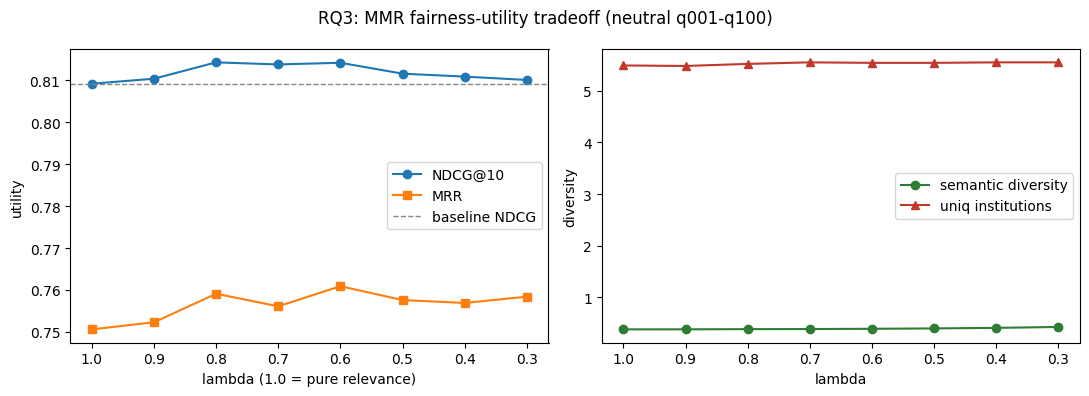

In [14]:
lams = [r['lambda'] for r in rows]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(lams, [r['NDCG@10'] for r in rows], 'o-', label='NDCG@10')
ax[0].plot(lams, [r['MRR'] for r in rows], 's-', label='MRR')
ax[0].axhline(baseline['NDCG@10'], ls='--', c='#888', lw=1, label='baseline NDCG')
ax[0].set_xlabel('lambda (1.0 = pure relevance)'); ax[0].set_ylabel('utility'); ax[0].legend(); ax[0].invert_xaxis()
ax[1].plot(lams, [r['sem_diversity'] for r in rows], 'o-', c='#2e7d32', label='semantic diversity')
ax[1].plot(lams, [r['uniq_institutions'] for r in rows], '^-', c='#c0392b', label='uniq institutions')
ax[1].set_xlabel('lambda'); ax[1].set_ylabel('diversity'); ax[1].legend(); ax[1].invert_xaxis()
fig.suptitle('RQ3: MMR fairness-utility tradeoff (neutral q001-q100)')
plt.tight_layout(); plt.savefig('rq3_lambda_ablation.png', dpi=120); plt.show()

## 7b. Institution-aware re-ranking (targets the project goal: institution)

Semantic MMR (Section 6) diversifies in embedding = **topic** space, so it barely moves the
institution metrics. Here the diversity term is computed on the **institution / country
labels** instead, so the re-ranker directly targets **institutional** diversity — the RQ3 goal.
We compare it against semantic MMR and watch the NDCG@10 cost and SPD (over-correction check).

In [15]:
def rerank_labelaware(pool, lam, field='institution', graded=True):
    """MMR-style re-ranking that diversifies on the INSTITUTION (or 'country') label
    instead of the embedding. score = lam*rel(d) - (1-lam)*penalty, where rel is the pool's
    rank-based relevance (seeded with the stored top-10, so lam=1.0 reproduces the baseline).
      graded=True : penalty = how many already-selected docs share d's group (0,1,2,...)
      graded=False: penalty = 1 if d's group already selected, else 0 (binary; saturates).
    Unlabeled candidates (no found affiliation) get no penalty."""
    cand = [(pid, rel) for (pid, rel, row) in pool]
    def group(pid):
        lab = label_of.get(pid)
        if lab and lab['coverage'] == 'found' and lab.get(field):
            return lab[field]
        return None
    selected, seen = [], Counter()
    while cand and len(selected) < K:
        best_i, best_score = None, -1e9
        for i, (pid, rel) in enumerate(cand):
            g = group(pid)
            if g is None:
                penalty = 0.0
            else:
                penalty = float(seen[g]) if graded else (1.0 if seen[g] > 0 else 0.0)
            s = lam * rel - (1 - lam) * penalty
            if s > best_score:
                best_score, best_i = s, i
        pid, rel = cand.pop(best_i)
        selected.append(pid)
        g = group(pid)
        if g is not None:
            seen[g] += 1
    return selected

# Finer grid near 1.0 so the graded ramp is visible (transition happens just below 1.0).
LAMBDAS_INST = [1.0, 0.99, 0.98, 0.97, 0.96, 0.95, 0.9, 0.8, 0.6, 0.4]
rows_inst = []
for lam in LAMBDAS_INST:
    m = evaluate(lambda pool, lam=lam: rerank_labelaware(pool, lam, field='institution', graded=True))
    m['lambda'] = lam; rows_inst.append(m)
    print(f"lam={lam}: NDCG={m['NDCG@10']} MRR={m['MRR']} "
          f"uInst={m['uniq_institutions']} uCtry={m['uniq_countries']} SPD={m['SPD']:+.3f}")

lam=1.0: NDCG=0.8092 MRR=0.7506 uInst=5.49 uCtry=4.04 SPD=+0.029
lam=0.99: NDCG=0.8092 MRR=0.7506 uInst=5.5 uCtry=4.05 SPD=+0.027
lam=0.98: NDCG=0.8093 MRR=0.752 uInst=5.56 uCtry=4.09 SPD=+0.029
lam=0.97: NDCG=0.8093 MRR=0.752 uInst=5.56 uCtry=4.09 SPD=+0.029
lam=0.96: NDCG=0.8091 MRR=0.752 uInst=5.58 uCtry=4.1 SPD=+0.025
lam=0.95: NDCG=0.8091 MRR=0.752 uInst=5.58 uCtry=4.1 SPD=+0.024
lam=0.9: NDCG=0.8087 MRR=0.752 uInst=5.66 uCtry=4.14 SPD=+0.020
lam=0.8: NDCG=0.809 MRR=0.752 uInst=5.73 uCtry=4.17 SPD=+0.016
lam=0.6: NDCG=0.809 MRR=0.752 uInst=5.73 uCtry=4.17 SPD=+0.017
lam=0.4: NDCG=0.809 MRR=0.752 uInst=5.73 uCtry=4.17 SPD=+0.017


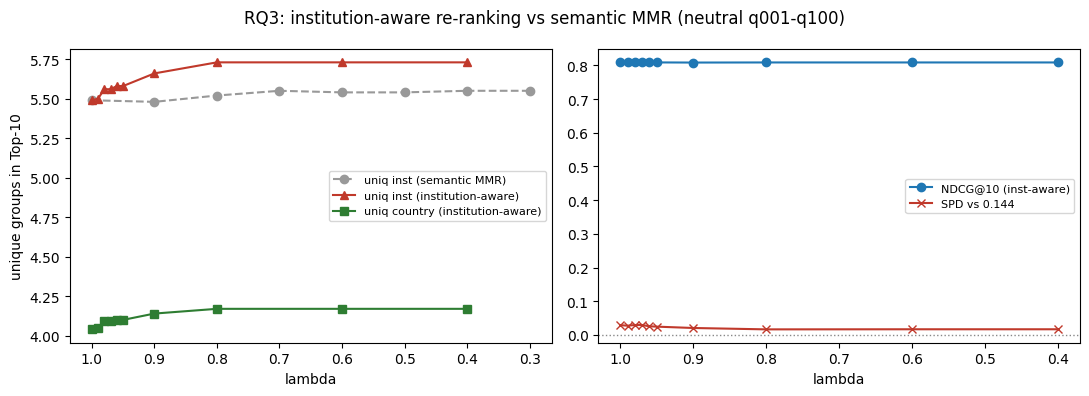

In [16]:
lam_s = [r['lambda'] for r in rows]        # semantic MMR grid
lam_i = [r['lambda'] for r in rows_inst]   # institution-aware grid (finer near 1.0)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
# left: institution / country diversity — semantic MMR vs institution-aware
ax[0].plot(lam_s, [r['uniq_institutions'] for r in rows], 'o--', c='#999',
           label='uniq inst (semantic MMR)')
ax[0].plot(lam_i, [r['uniq_institutions'] for r in rows_inst], '^-', c='#c0392b',
           label='uniq inst (institution-aware)')
ax[0].plot(lam_i, [r['uniq_countries'] for r in rows_inst], 's-', c='#2e7d32',
           label='uniq country (institution-aware)')
ax[0].set_xlabel('lambda'); ax[0].set_ylabel('unique groups in Top-10')
ax[0].legend(fontsize=8); ax[0].invert_xaxis()
# right: utility cost + SPD (over-correction check)
ax[1].plot(lam_i, [r['NDCG@10'] for r in rows_inst], 'o-', label='NDCG@10 (inst-aware)')
ax[1].plot(lam_i, [r['SPD'] for r in rows_inst], 'x-', c='#c0392b', label='SPD vs 0.144')
ax[1].axhline(0, ls=':', c='#888', lw=1)
ax[1].set_xlabel('lambda'); ax[1].legend(fontsize=8); ax[1].invert_xaxis()
fig.suptitle('RQ3: institution-aware re-ranking vs semantic MMR (neutral q001-q100)')
plt.tight_layout(); plt.savefig('rq3_institution_ablation.png', dpi=120); plt.show()

In [17]:
# Bootstrap 95% CI on the institution-diversity gain (baseline -> institution-aware),
# resampling over queries (same style as RQ1). Uses the diversity-plateau lambda.
INST_LAMBDA = 0.9

def per_query_uinst(ranker):
    vals = []
    for q, pool in zip(queries, pools):
        _, _, ni, _ = label_stats(ranker(pool))
        vals.append(ni)
    return np.array(vals, dtype=float)

base_ui = per_query_uinst(lambda pool: [pid for (pid, _, _) in pool[:K]])
inst_ui = per_query_uinst(lambda pool: rerank_labelaware(pool, INST_LAMBDA, field='institution', graded=True))
diff = inst_ui - base_ui

idx = np.arange(len(diff))
boot = np.array([diff[rng.choice(idx, size=len(idx), replace=True)].mean() for _ in range(5000)])
ci = np.percentile(boot, [2.5, 97.5])
diversity_ci = {'lambda': INST_LAMBDA,
                'mean_gain_uniq_institutions': round(float(diff.mean()), 3),
                'ci95': [round(float(ci[0]), 3), round(float(ci[1]), 3)],
                'significant': bool(ci[0] > 0)}
print(f"uniq-institution gain (baseline -> inst-aware, lam={INST_LAMBDA}): "
      f"{diff.mean():+.3f}  95% CI [{ci[0]:+.3f}, {ci[1]:+.3f}]  "
      f"-> {'SIGNIFICANT' if ci[0] > 0 else 'not significant'} (CI excludes 0: {ci[0] > 0})")

uniq-institution gain (baseline -> inst-aware, lam=0.9): +0.170  95% CI [+0.090, +0.260]  -> SIGNIFICANT (CI excludes 0: True)


## 7c. Bootstrap CI on SPD itself

Section 7b swept lambda from 1.0 to 0.4 and showed that unique_institutions
plateaus at lambda=0.8 (no further gain at 0.6 or 0.4), NDCG@10 stays flat
across the whole sweep, and SPD reaches its lowest point around lambda=0.8.
Based on this diversity/utility tradeoff -- not on the SPD significance test
itself -- lambda=0.8 is selected as the operating point for this section.

This section asks: at that chosen operating point, is SPD itself -- both the
post-rerank value and the improvement vs baseline -- statistically
significant, using the same query-resampling bootstrap as RQ1 (Step 5b)?

`evaluate()` only returns a POOLED SPD number per lambda, with no per-query
breakdown, so it cannot be bootstrapped directly. We add a per-query
elite/found extractor and reuse the RQ1 bootstrap logic (resample queries
with replacement, recompute the pooled share each draw, seed=42, n_boot=10000).

Two separate checks:
- (A) Absolute: is the institution-aware SPD (at `BEST_LAMBDA`) itself
  different from 0?
- (B) Improvement: is the DROP from baseline SPD to institution-aware SPD
  itself significant, using a paired bootstrap (same resampled query indices
  applied to both arms)?

In [18]:
# Section 7c: Bootstrap CI on SPD itself (both the absolute value and the
# improvement vs baseline), using the same query-resampling logic as RQ1.

# Operating point chosen from the Section 7b sweep: diversity plateau + lowest
# SPD + no NDCG loss around lambda=0.8. Independent variable from Section 7b's
# INST_LAMBDA (0.9), which was used there only to illustrate the trend.
BEST_LAMBDA = 0.8

def per_query_elite_found(ranker):
    """Return per-query (elite_count, found_count) arrays for bootstrap."""
    elites, founds = [], []
    for q, pool in zip(queries, pools):
        top = ranker(pool)
        nf, ne, ni, nc = label_stats(top)
        elites.append(ne); founds.append(nf)
    return np.array(elites, dtype=float), np.array(founds, dtype=float)

def bootstrap_spd(elites, founds, baseline_share=BASELINE_SHARE, n_boot=10000, seed=42):
    """Resample queries with replacement, recompute pooled share each draw,
    return (mean SPD, 95% CI). Mirrors the RQ1 bootstrap methodology."""
    rng_local = np.random.default_rng(seed)
    idx = np.arange(len(elites))
    boots = []
    for _ in range(n_boot):
        samp = rng_local.choice(idx, size=len(idx), replace=True)
        e, f = elites[samp].sum(), founds[samp].sum()
        boots.append(e / f - baseline_share if f > 0 else np.nan)
    boots = np.array(boots)
    return float(np.nanmean(boots)), [float(x) for x in np.nanpercentile(boots, [2.5, 97.5])]

# (A) Is the institution-aware SPD itself significantly different from 0?
inst_elites, inst_founds = per_query_elite_found(
    lambda pool: rerank_labelaware(pool, BEST_LAMBDA, field='institution', graded=True))
spd_mean, spd_ci = bootstrap_spd(inst_elites, inst_founds)
print(f"Institution-aware SPD (lam={BEST_LAMBDA}): {spd_mean:+.4f}  95% CI {spd_ci}")

# (B) Is the SPD IMPROVEMENT (baseline -> institution-aware) itself significant?
#     Paired bootstrap: same resampled query indices applied to both arms.
base_elites, base_founds = per_query_elite_found(lambda pool: [pid for (pid, _, _) in pool[:K]])
idx = np.arange(len(inst_elites))
rng_local = np.random.default_rng(42)
diffs = []
for _ in range(10000):
    samp = rng_local.choice(idx, size=len(idx), replace=True)
    share_base = base_elites[samp].sum() / base_founds[samp].sum()
    share_inst = inst_elites[samp].sum() / inst_founds[samp].sum()
    diffs.append(share_base - share_inst)   # positive = SPD improved (got smaller)
diffs = np.array(diffs)
spd_improvement_ci = {
    'lambda': BEST_LAMBDA,
    'lambda_selection': 'chosen from the Section 7b sweep (diversity plateau, '
                         'lowest SPD, no NDCG loss), not selected via this test',
    'mean_improvement': round(float(diffs.mean()), 4),
    'ci95': [round(float(x), 4) for x in np.percentile(diffs, [2.5, 97.5])],
    'significant': bool(np.percentile(diffs, 2.5) > 0),
}
print(f"SPD improvement (base - inst): {diffs.mean():+.4f}  95% CI {spd_improvement_ci['ci95']}")

Institution-aware SPD (lam=0.8): +0.0162  95% CI [-0.01394902730016781, 0.048374428721058606]
SPD improvement (base - inst): +0.0126  95% CI [0.0013, 0.0254]


## 7d. Visualizing the three significance checks together

Three separate bootstrap checks were run at the chosen operating point
(institution-aware re-ranking, lambda=0.8 unless noted):
1. Diversity gain (unique institutions, lambda=0.9 sweep point from 7b)
2. Absolute SPD after re-ranking (7c-A)
3. SPD improvement, baseline -> re-ranked (7c-B)

A forest-plot-style chart makes it easy to see at a glance which checks'
95% CIs cross zero (not significant) and which don't (significant), without
needing to compare three separate printed numbers.

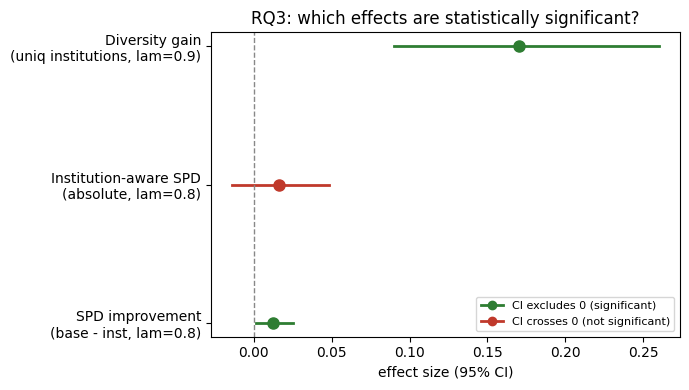

In [21]:
# Section 7d: forest-plot summary of the three bootstrap checks
fig, ax = plt.subplots(figsize=(7, 4))

checks = [
    ('Diversity gain\n(uniq institutions, lam=0.9)',
     diversity_ci['mean_gain_uniq_institutions'], diversity_ci['ci95']),
    ('Institution-aware SPD\n(absolute, lam=0.8)',
     spd_mean, spd_ci),
    ('SPD improvement\n(base - inst, lam=0.8)',
     spd_improvement_ci['mean_improvement'], spd_improvement_ci['ci95']),
]

ys = list(range(len(checks)))[::-1]
for y, (label, mean, ci) in zip(ys, checks):
    lo, hi = ci
    significant = (lo > 0) or (hi < 0)
    color = '#2e7d32' if significant else '#c0392b'
    ax.plot([lo, hi], [y, y], '-', color=color, lw=2)
    ax.plot(mean, y, 'o', color=color, ms=8)

ax.axvline(0, ls='--', c='#888', lw=1)
ax.set_yticks(ys)
ax.set_yticklabels([c[0] for c in checks])
ax.set_xlabel('effect size (95% CI)')
ax.set_title('RQ3: which effects are statistically significant?')

# simple legend via proxy artists
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], color='#2e7d32', lw=2, marker='o', label='CI excludes 0 (significant)'),
    Line2D([0], [0], color='#c0392b', lw=2, marker='o', label='CI crosses 0 (not significant)'),
]
ax.legend(handles=legend_elems, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('rq3_spd_significance.png', dpi=120)
plt.show()

## 8. Save results (updated)

Adds the two new bootstrap results from Section 7c to the saved payload,
alongside the existing baseline / lambda-sweep / diversity-gain results:

- `spd_absolute_ci`: mean and 95% CI of the institution-aware SPD at
  `INST_LAMBDA`, testing whether it differs from 0.
- `spd_improvement_ci`: mean and 95% CI of the SPD improvement
  (baseline SPD - institution-aware SPD), testing whether the drop itself
  is significant, plus a boolean `significant` flag (CI excludes 0).

No other fields in `out` change; schema stays otherwise identical so
downstream report code does not break.

In [20]:
out = {'baseline': baseline,
       'mmr_semantic_by_lambda': rows,
       'mmr_institution_by_lambda': rows_inst,
       'diversity_gain_ci': diversity_ci,
       'spd_absolute_ci': {'lambda': BEST_LAMBDA, 'mean': spd_mean, 'ci95': spd_ci},
       'spd_improvement_ci': spd_improvement_ci,
       'config': {'baseline_share': BASELINE_SHARE, 'n_candidates': N_CANDIDATES,
                  'k': K, 'n_queries': len(queries), 'elite': 'QS Top-50',
                  'baseline_source': 'stored Step 5a top-10 (retrieval_results.json)'}}
os.makedirs('results', exist_ok=True)
with open('results/rq3_results.json', 'w') as f:
    json.dump(out, f, indent=2)
with open('rq3_results.json', 'w') as f:  # Kaggle working dir
    json.dump(out, f, indent=2)
print('saved results/rq3_results.json')

saved results/rq3_results.json
